In [10]:
%pip install yfinance matplotlib

  Using cached matplotlib-3.9.4-cp39-cp39-win_amd64.whl.metadata (11 kB)
  Using cached contourpy-1.3.0-cp39-cp39-win_amd64.whl.metadata (5.4 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached fonttools-4.60.2-cp39-cp39-win_amd64.whl.metadata (115 kB)
  Using cached kiwisolver-1.4.7-cp39-cp39-win_amd64.whl.metadata (6.4 kB)
  Using cached pillow-11.3.0-cp39-cp39-win_amd64.whl.metadata (9.2 kB)
  Using cached importlib_resources-6.5.2-py3-none-any.whl.metadata (3.9 kB)
Using cached matplotlib-3.9.4-cp39-cp39-win_amd64.whl (7.8 MB)
Using cached contourpy-1.3.0-cp39-cp39-win_amd64.whl (211 kB)
Using cached cycler-0.12.1-py3-none-any.whl (8.3 kB)
Using cached fonttools-4.60.2-cp39-cp39-win_amd64.whl (1.5 MB)
Using cached importlib_resources-6.5.2-py3-none-any.whl (37 kB)
Using cached kiwisolver-1.4.7-cp39-cp39-win_amd64.whl (55 kB)
Using cached pillow-11.3.0-cp39-cp39-win_amd64.whl (7.0 MB)

   ---------------------------------------- 0/8 [pyparsing]
   ----

In [42]:
import yfinance as yf

stocks = ["RELIANCE.NS", "TCS.NS", "HDFCBANK.NS"]
data = yf.download(stocks, start="2022-01-01")

data = data["Close"]   
print(data.head())

[*********************100%***********************]  3 of 3 completed

Ticker      HDFCBANK.NS  RELIANCE.NS       TCS.NS
Date                                             
2022-01-03   722.802551  1093.780640  3386.357666
2022-01-04   727.035706  1118.464966  3445.786865
2022-01-05   744.301331  1123.697754  3424.676025
2022-01-06   732.362854  1099.536499  3377.221680
2022-01-07   737.499817  1108.409302  3418.068604


In [43]:
#calculate returns
returns = data.pct_change().dropna()
#define portfolio weights
weights = [0.4, 0.3, 0.3]  
# portfolio returns
portfolio_returns = returns.dot(weights)

In [44]:
print(returns.head())

Ticker      HDFCBANK.NS  RELIANCE.NS    TCS.NS
Date                                          
2022-01-04     0.005857     0.022568  0.017550
2022-01-05     0.023748     0.004679 -0.006127
2022-01-06    -0.016040    -0.021502 -0.013857
2022-01-07     0.007014     0.008070  0.012095
2022-01-10     0.005546     0.000821  0.006838


In [45]:
print(portfolio_returns.head())

Date
2022-01-04    0.014378
2022-01-05    0.009065
2022-01-06   -0.017023
2022-01-07    0.008855
2022-01-10    0.004516
dtype: float64


In [46]:
#calculate VaR
import numpy as np

var_95 = np.percentile(portfolio_returns, 5)

print("VaR (95%):", var_95)

VaR (95%): -0.01593592484336135


In [47]:
cvar_95 = portfolio_returns[portfolio_returns <= var_95].mean()

print("CVaR (95%):", cvar_95)

CVaR (95%): -0.022443651089253135


In [51]:
threshold = np.percentile(portfolio_returns, 20)

stress_period = portfolio_returns[portfolio_returns <= threshold]

In [52]:
#compute svar
svar_95 = np.percentile(stress_period, 5)

print("SVaR (95%):", svar_95)

SVaR (95%): -0.026050475131906455


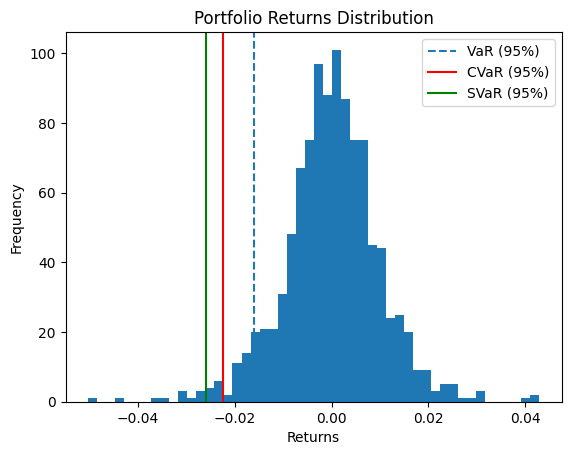

In [66]:
import matplotlib.pyplot as plt

plt.hist(portfolio_returns, bins=50)
plt.axvline(var_95, linestyle='dashed', label='VaR (95%)')
plt.axvline(cvar_95, color = "r",  label='CVaR (95%)')
plt.axvline(svar_95, color ='g',  label='SVaR (95%)')
plt.title("Portfolio Returns Distribution")
plt.xlabel("Returns")
plt.ylabel("Frequency")
plt.legend()
plt.savefig("outputs/returns_distribution.png")
plt.show()
plt.close()

In [67]:
import os
os.makedirs("outputs", exist_ok=True)
portfolio_returns_df = portfolio_returns.reset_index()
portfolio_returns_df.columns = ["Date", "Portfolio_Return"]

portfolio_returns_df.to_csv("outputs/portfolio_returns.csv", index=False)


portfolio_value = 100000  

with open("outputs/market_risk_report.txt", "w") as f:
    f.write("=== Market Risk Report ===\n\n")
    f.write(f"Portfolio Value: Rs{portfolio_value}\n\n")
    
    f.write("Risk Metrics:\n")
    f.write("----------------------\n")
    f.write(f"VaR (95%): {var_95:.4f} ({var_95*100:.2f}%) | Rs{var_95*portfolio_value:.2f}\n")
    f.write(f"CVaR (95%): {cvar_95:.4f} ({cvar_95*100:.2f}%) | Rs{cvar_95*portfolio_value:.2f}\n")
    f.write(f"SVaR (95%): {svar_95:.4f} ({svar_95*100:.2f}%) | Rs{svar_95*portfolio_value:.2f}\n")